# E-Commerce User Behavior Analysis


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/raw/events_sample.csv")
df.head()


,timestamp,visitorid,event,itemid,transactionid
0,1767225660000,1119,view,1107,NaN
1,1767225720000,1080,view,1183,NaN
2,1767225720000,367,view,1143,NaN
3,1767226020000,1080,view,1245,NaN
4,1767226080000,1080,addtocart,1245,NaN


In [4]:
print(df.shape)
df.info()


(20000, 5)
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      20000 non-null  int64  
 1   visitorid      20000 non-null  int64  
 2   event          20000 non-null  str    
 3   itemid         20000 non-null  int64  
 4   transactionid  660 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 872.9 KB


In [5]:
df.isnull().sum()


timestamp            0
visitorid            0
event                0
itemid               0
transactionid    19340
dtype: int64

In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
df["event"].value_counts()


event
view           17530
addtocart       1810
transaction      660
Name: count, dtype: int64

In [8]:
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.day_name()
df.head()


,timestamp,visitorid,event,itemid,transactionid,datetime,date,hour,day_of_week
0,1767225660000,1119,view,1107,NaN,2026-01-01 00:01:00+00:00,2026-01-01,0,Thursday
1,1767225720000,1080,view,1183,NaN,2026-01-01 00:02:00+00:00,2026-01-01,0,Thursday
2,1767225720000,367,view,1143,NaN,2026-01-01 00:02:00+00:00,2026-01-01,0,Thursday
3,1767226020000,1080,view,1245,NaN,2026-01-01 00:07:00+00:00,2026-01-01,0,Thursday
4,1767226080000,1080,addtocart,1245,NaN,2026-01-01 00:08:00+00:00,2026-01-01,0,Thursday


In [9]:
event_counts = df["event"].value_counts()
views = event_counts.get("view", 0)
carts = event_counts.get("addtocart", 0)
purchases = event_counts.get("transaction", 0)
view_to_cart = carts / views * 100 if views else 0
cart_to_purchase = purchases / carts * 100 if carts else 0
view_to_purchase = purchases / views * 100 if views else 0
print(f"View -> Cart: {view_to_cart:.2f}%")
print(f"Cart -> Purchase: {cart_to_purchase:.2f}%")
print(f"View -> Purchase: {view_to_purchase:.2f}%")


View -> Cart: 10.33%
Cart -> Purchase: 36.46%
View -> Purchase: 3.76%


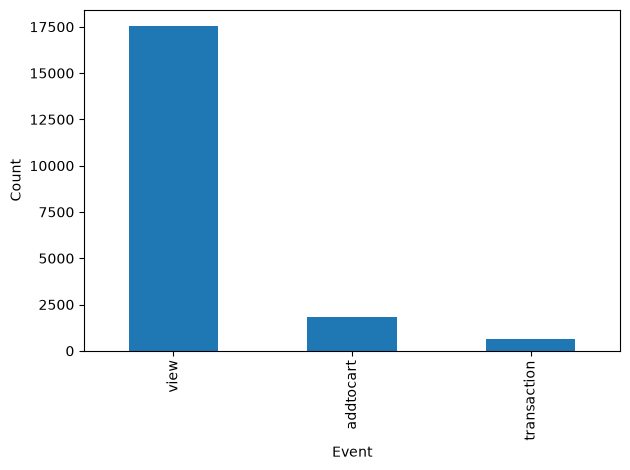

In [10]:
df["event"].value_counts().plot(kind="bar")
plt.xlabel("Event")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [11]:
df.groupby("visitorid").size().sort_values(ascending=False).head(10)


visitorid
371     35
934     32
562     31
1081    31
1128    30
619     30
90      30
435     30
495     30
202     30
dtype: int64

In [12]:
df.groupby("itemid").size().sort_values(ascending=False).head(10)


itemid
1183    85
1122    82
1138    78
1106    77
1013    76
1082    76
1295    76
1330    75
1233    75
1262    74
dtype: int64